# Praktikum Simple Linear Regression & Multiple Linear Regression

**Nama** : Christina Adelia Sitinjak  
**NIM** : 42324056    

## Simple Linear Regression

In [2]:
import pandas as pd
df = pd.read_csv('Salary_Data.csv')
print(df.head())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


**Penjelasan:** Kode di atas untuk membukafile `Salary_Data.csv` pakai pandas, terus disimpan ke variabel `df`. `df.head()` dipakai buat lihat 5 baris data pertama, sekalian ngecek datanya kebaca dengan benar.

In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

**Penjelasan:** Kode di atas untuk `X` diisi kolom `YearsExperience` (variabel bebas/predictor), sedangkan `y` diisi kolom `Salary` (variabel yang mau diprediksi). Keduanya harus dipisah dulu sebelum bisa dipakai buat training model.

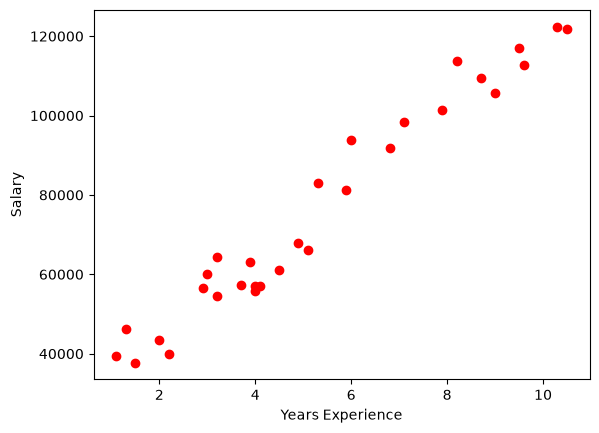

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X, y, color = "red")
plt.xlabel('Years Experience')
plt.ylabel('Salary')
plt.show()

**Penjelasan:** Scatter plot ini buat lihat pola hubungan antara experience dan salary sebelum dimodelkan. Kalau titik-titiknya kelihatan naik lurus kayak gini, artinya cocok dipakai regresi linear.

In [6]:
#bagi dataset jadi train dan test 80:20
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

**Penjelasan:** Kode di atas digunakan agar data dibagi jadi 80% buat training (melatih model) dan 20% buat testing (menguji model). `random_state = 0` dipakai supaya hasil pembagian datanya konsisten tiap kali kode dijalankan ulang, nggak berubah-ubah karena acak. 

In [7]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9312.58]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.678e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[12.65]


**Penjelasan:** Kode di atas untuk membuat objek model `LinearRegression()`, terus dilatih (`fit`) pakai data training. Di tahap ini model belajar nyari garis lurus terbaik yang paling pas sama data experience dan salary.

In [8]:
a = regressor.intercept_
b = regressor.coef_[0]

print("Estimated model intercept, a:", a)
print("Estimated model slope, b:", b)
print(f"y_hat = {a:.2f} + {b:.2f}x")

Estimated model intercept, a: 26780.09915062818
Estimated model slope, b: 9312.575126729189
y_hat = 26780.10 + 9312.58x


**Penjelasan:** Setelah dilatih, model ini punya 2 nilai penting: `intercept` (a, nilai salary saat experience = 0) dan `slope` (b, seberapa besar salary naik tiap tambah 1 tahun experience). Dua nilai ini dipakai buat nyusun persamaan garis regresinya.

In [9]:
# memprediksi hasil pada data uji (Test set) menggunakan model regresi yang telah dilatih
y_pred = regressor.predict(X_test)
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

**Penjelasan:** Model yang udah dilatih dipakai buat nebak salary dari `X_test`, data yang belum pernah dilihat model sebelumnya. Hasilnya berupa angka-angka prediksi yang nanti dibandingin sama nilai salary aslinya.

In [10]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# Semakin mendekati 1, semakin baik model

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
score

0.988169515729126

**Penjelasan:** R² ngukur seberapa bagus model ini dalam menjelaskan data, dengan cara membandingkan `y_pred` (hasil prediksi) sama `y_test` (nilai asli). Nilainya berkisar 0-1, makin deket ke 1 berarti modelnya makin akurat.

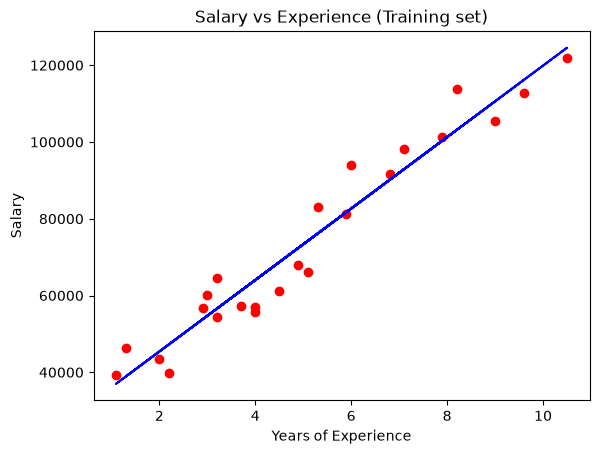

In [11]:
# Visualizing the Training set results
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

**Penjelasan:** Grafik ini nunjukin garis regresi (biru) yang dihasilkan model, dibandingin sama titik-titik data training aslinya (merah). Kalau garisnya udah deket sama titik-titiknya, berarti model udah cukup pas ngikutin pola data.

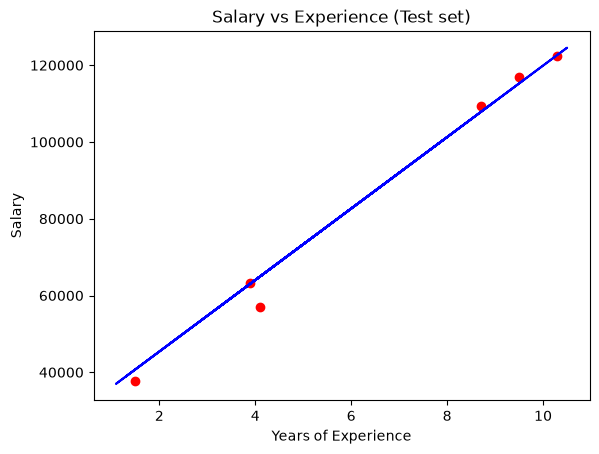

In [12]:
# Visualizing the Test set results
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

**Penjelasan:** Sama seperti grafik sebelumnya, tapi sekarang garis regresinya dibandingkan dengan data test (yang belum pernah dipelajari model). Ini untuk mengecek apakah model masih akurat walaupun ketemu data baru.

## Multiple Linear Regression

In [13]:
df2 = pd.read_csv('multiple_linear_regression_dataset.csv')
print(df2.head())

   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


**Penjelasan:** Kode di atas untuk membuka dataset baru yang punya 2 variabel bebas sekaligus: `age` (umur) dan `experience` (pengalaman kerja), buat diprediksi ke `income` (pendapatan).

In [14]:
X2 = df2.iloc[:, :-1]
y2 = df2.iloc[:, 2]

**Penjelasan:** `X2` sekarang isinya 2 kolom (age dan experience) karena ini Multiple Linear Regression, beda dari sebelumnya yang hanya 1 predictor. `y2` tetap 1 kolom, yaitu `income`.

In [15]:
# Bagi dataset menjadi train dan test 80:20

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 0)

**Penjelasan:** Sama seperti sebelumnya, data dipecah 80% training dan 20% testing, dengan `random_state = 0` agar hasilnya konsisten tiap dijalankan ulang.

In [16]:
regressor = LinearRegression()
regressor.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -97.99,2205.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


**Penjelasan:** Model dilatih lagi, tapi kali ini belajar dari 2 variabel bebas sekaligus (age dan experience), bukan cuma 1 seperti Simple Linear Regression tadi.

In [17]:
# Predicting the Test set results
y_pred2 = regressor.predict(X_test2)
print(y_pred2)

[46487.25542968 34623.71312375 49379.11875301 38349.57565764]


**Penjelasan:** Model dipakai untuk menebak income dari data test, sama seperti proses prediksi di Simple Linear Regression sebelumnya.

In [18]:
a_ = regressor.intercept_
b1 = regressor.coef_[0]
b2 = regressor.coef_[1]

print("Estimated model intercept, a:", a_)
print("Estimated model slope, b1:", b1)
print("Estimated model slope, b2:", b2)
print(f"y_hat = {a_:.2f} {b1:.2f}x1 + {b2:.2f}x2")

Estimated model intercept, a: 30945.793141906892
Estimated model slope, b1: -97.99352917934205
Estimated model slope, b2: 2205.9086190738694
y_hat = 30945.79 -97.99x1 + 2205.91x2


**Penjelasan:** Karena predictornya ada 2, sekarang ada 2 koefisien slope (`b1` buat age, `b2` buat experience), bukan hanya 1 seperti Simple Linear Regression. Persamaan regresinya jadi memiliki 2 variabel `x1` dan `x2`.

In [19]:
# Menghitung nilai R-Square, yang mengukur seberapa baik model regresi linear
# Semakin mendekati 1, semakin baik model

score2 = r2_score(y_test2, y_pred2)
score2

0.8872690560355565